# Neural Network Training Tips & Tricks

This notebook is a hands-on tour through the practical techniques that turn a working training loop into a **good** one. For every trick we show **what it does**, **how to add it in code**, and **what measurable effect** it has on training.

You will:
1. See an overview of the [`timm`](https://huggingface.co/timm) model zoo.
2. Build a training loop step-by-step — starting from a naive 5-line version and adding features one at a time.
3. Compare optimizers, schedulers, and "tricks" (gradient clipping, gradient accumulation, EMA, label smoothing, AMP) on the **same dataset, same model, same seed** so you can see the effect.
4. Use diagnostic tools — `lr_finder` and `weight_decay_finder` — to pick hyperparameters instead of guessing.
5. Solve six exercises that build on the techniques.

> **Runs on Colab GPU** by default; auto-detects CPU / MPS / CUDA. AMP is **opt-in** and turned off where it would hurt or where the device doesn't support it.

## [Open in Colab](https://colab.research.google.com/github/MVRonkin/DLCVCourseEn/tree/main/WS/WS4_Tricks_In_Train_EN.ipynb)

> On Colab: **Runtime → Change runtime type → T4 GPU** before running.

## References

* PyTorch [optimizer guide](https://docs.pytorch.org/docs/stable/optim.html)
* [`timm`](https://huggingface.co/docs/timm) — PyTorch Image Models
* [`torchmetrics`](https://github.com/Lightning-AI/torchmetrics)
* [Bag of Tricks for Image Classification](https://arxiv.org/abs/1812.01187) — He et al., 2019
* [How to Decide on Learning Rate](https://towardsdatascience.com/how-to-decide-on-learning-rate-6b6996510c98)

# 1. Imports and reproducibility setup

In [17]:
!pip install --quiet -U timm torchmetrics torchinfo

In [18]:
import os
import time
import random
import gc
import warnings
from contextlib import nullcontext
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.backends.cudnn as cudnn
from torch.utils.data import DataLoader
from torchvision import transforms, datasets
from torchvision.datasets.utils import download_and_extract_archive

import timm
from torchmetrics import Accuracy, Precision, Recall, F1Score
from torchinfo import summary

warnings.filterwarnings("ignore", category=UserWarning)

## `setup_experiment` — reproducibility in one call

The first thing every training script needs is a deterministic, predictable starting state. This helper sets seeds across `random` / `numpy` / `torch`, configures cuDNN, enables TF32 on Ampere+ GPUs, and picks the best available device.

> **What it gives you:** swapping the seed flips experiments to a different random draw; running with the same seed twice yields nearly identical curves. This is what makes "before/after" comparisons in the rest of the notebook trustworthy.

In [19]:
def setup_experiment(seed=42, deterministic=False, allow_tf32=True, device_preference="auto"):
    """
    Seed everything and pick a device.

    Args:
        seed: master seed for random / numpy / torch.
        deterministic: if True, cuDNN is forced into deterministic mode (slower).
                       Default False because benchmark=True is much faster on Colab.
        allow_tf32: enable TF32 matmul on Ampere+ — ~2x faster, tiny accuracy cost.
        device_preference: 'auto' | 'cuda' | 'mps' | 'cpu'.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        cudnn.deterministic = deterministic
        cudnn.benchmark = not deterministic
        if allow_tf32:
            torch.backends.cuda.matmul.allow_tf32 = True
            torch.backends.cudnn.allow_tf32 = True

    if device_preference == "auto":
        if torch.cuda.is_available():
            device = torch.device("cuda")
        elif torch.backends.mps.is_available():
            device = torch.device("mps")
        else:
            device = torch.device("cpu")
    else:
        device = torch.device(device_preference)

    print(f"[✓] Device: {device} | Seed: {seed} | TF32: {allow_tf32}")
    return device


device = setup_experiment(seed=42)

[✓] Device: cpu | Seed: 42 | TF32: True


# 2. Overview of the `timm` library

[`timm`](https://huggingface.co/timm) (PyTorch Image Models) is the most comprehensive collection of pretrained vision backbones in the PyTorch ecosystem — over 1000 architectures, all loadable with one function call and all sharing a consistent API: `create_model`, `get_classifier`, `reset_classifier`, `forward_features`, etc.

You can search the catalog by glob pattern:

In [20]:
# All MobileNet-family models
print(timm.list_models('mobilev*')[:10])
print('...')
# All ViT-tiny variants
print(timm.list_models('*vit_tiny*')[:5])

['mobilevit_s', 'mobilevit_xs', 'mobilevit_xxs', 'mobilevitv2_050', 'mobilevitv2_075', 'mobilevitv2_100', 'mobilevitv2_125', 'mobilevitv2_150', 'mobilevitv2_175', 'mobilevitv2_200']
...
['convit_tiny', 'crossvit_tiny_240', 'davit_tiny', 'gcvit_tiny', 'maxvit_tiny_pm_256']


## Loading a model and inspecting its head

`create_model` is the single entry point. Three flags matter most:

* `pretrained=True` — download ImageNet-1k weights from the Hub.
* `num_classes=N` — replace the final linear layer with one for `N` classes (initialized from scratch).
* `in_chans=C` — adjust the first conv if your data isn't 3-channel.

In [21]:
model = timm.create_model('mobilenetv3_small_050', pretrained=True, num_classes=2)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Classifier: {model.get_classifier()}")

Parameters: 570,274
Classifier: Linear(in_features=1024, out_features=2, bias=True)


## Replacing the head with a custom one

A common pattern: keep the pretrained backbone frozen, attach a small MLP on top.

In [22]:
# Freeze the whole network ...
for p in model.parameters():
    p.requires_grad = False

# ... then swap the head with a custom MLP and let it train
in_features = model.get_classifier().in_features
model.classifier = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(in_features, 128),
    nn.ReLU(),
    nn.Linear(128, 2),
)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable: {trainable:,} / {total:,}  ({100*trainable/total:.2f}%)")

Trainable: 131,458 / 699,682  (18.79%)


> **Tip — `forward_features`:** if you only need embeddings (e.g. for similarity search or feeding into your own classifier), call `model.forward_features(x)` to skip the head entirely. The output shape depends on the architecture; check `model.feature_info` for details.

# 3. Dataset — bees vs ants

We use the small `hymenoptera_data` dataset (≈245 train / 153 val images of bees and ants) — small enough that an epoch on a T4 GPU is a few seconds, large enough that training tricks make a visible difference.

In [23]:
url = 'https://download.pytorch.org/tutorial/hymenoptera_data.zip'
root_directory = os.path.join(os.getcwd(), 'data')
archive_name = url.split('/')[-1]
dataset_directory = os.path.splitext(os.path.join(root_directory, archive_name))[0]
download_and_extract_archive(url, root_directory)
print(f"Dataset at: {dataset_directory}")

Dataset at: C:\Users\Ronkin\Documents\GitHub\Computer-Vision-Course_lec-practice\2025\LEC\data\hymenoptera_data


In [24]:
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]
BATCH_SIZE = 16

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

trainset = datasets.ImageFolder(os.path.join(dataset_directory, 'train'), train_transform)
valset   = datasets.ImageFolder(os.path.join(dataset_directory, 'val'),   val_transform)

trainloader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True,
                         num_workers=2, pin_memory=True)
valloader   = DataLoader(valset,   batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=2, pin_memory=True)

num_classes = len(trainset.classes)
class_names = trainset.classes
print(f"Classes: {class_names} | train={len(trainset)}, val={len(valset)}")

Classes: ['ants', 'bees'] | train=244, val=153


# 4. The naive training loop — and what's wrong with it

Before adding tricks, let's establish a baseline. Here is the **minimal** correct training loop in PyTorch — five logical steps per batch, ~15 lines for the whole loop:

In [25]:
def naive_train(model, loader, optimizer, criterion, device, epochs=3):
    model.train()
    history = []
    for epoch in range(epochs):
        epoch_loss = 0.0
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()         # 1. clear old gradients
            logits = model(x)             # 2. forward
            loss = criterion(logits, y)   # 3. loss
            loss.backward()               # 4. backward
            optimizer.step()              # 5. update
            epoch_loss += loss.item()
        avg = epoch_loss / len(loader)
        history.append(avg)
        print(f"  Epoch {epoch+1}: train_loss={avg:.4f}")
    return history

**Run it once just to confirm everything works.** We use a small ViT, freeze the backbone, and train only the head for 3 epochs.

In [26]:
def make_model():
    m = timm.create_model('mobilenetv3_small_050', pretrained=True, num_classes=num_classes)
    for p in m.parameters():
        p.requires_grad = False
    m.get_classifier().requires_grad_(True)
    return m.to(device)

setup_experiment(seed=42)
m = make_model()
opt = torch.optim.AdamW(filter(lambda p: p.requires_grad, m.parameters()), lr=1e-3)
crit = nn.CrossEntropyLoss()

print("Naive baseline:")
_ = naive_train(m, trainloader, opt, crit, device, epochs=3)

[✓] Device: cpu | Seed: 42 | TF32: True
Naive baseline:
  Epoch 1: train_loss=2.2068
  Epoch 2: train_loss=1.7953
  Epoch 3: train_loss=1.9172


**What's missing?** The naive loop trains, but it gives us no answers to questions a real project asks:

| Question | What's missing |
|---|---|
| Is the model overfitting? | No validation loop. |
| Which epoch was best? | No checkpointing. |
| Should I stop early? | No early stopping. |
| What's my LR doing over time? | No scheduler, no LR logging. |
| Are gradients exploding? | No gradient clipping or norm tracking. |
| Can I fit a bigger model? | No AMP, no gradient accumulation. |
| Did the run actually converge or just luck? | No EMA, no smoothing. |

The next sections fix each of these — one at a time, with measurable before/after.

# 5. Validation metrics with `torchmetrics`

[`torchmetrics`](https://github.com/Lightning-AI/torchmetrics) is the standard library for multi-class metrics. Each metric is a callable object that takes `(predictions, targets)` and lives on the same device as your model.

> Recall: `average='macro'` averages per class (treating all classes equally), `'micro'` averages over all samples (weighted by class size), `'weighted'` averages per class but weighted by support.

In [27]:
metrics = {
    'acc':  Accuracy(task='multiclass', num_classes=num_classes).to(device),
    'prec': Precision(task='multiclass', num_classes=num_classes, average='macro').to(device),
    'rec':  Recall(task='multiclass', num_classes=num_classes, average='macro').to(device),
    'f1':   F1Score(task='multiclass', num_classes=num_classes, average='macro').to(device),
}
metrics

{'acc': MulticlassAccuracy(),
 'prec': MulticlassPrecision(),
 'rec': MulticlassRecall(),
 'f1': MulticlassF1Score()}

# 6. A proper training step — `train_epoch` and `evaluate_epoch`

We now extract one epoch into a function and add the things that were missing: validation, per-batch and per-epoch metrics, optional **gradient clipping**, optional **AMP**, optional **gradient accumulation**, optional **EMA**.

Each option is a single keyword argument. Keep them off to reproduce the naive behaviour, turn them on to see the effect.

In [28]:
def train_epoch(model, loader, optimizer, criterion, metrics, device, *,
                use_amp=False, grad_clip=None, ema=None, accumulation_steps=1):
    """
    One epoch of training.

    use_amp:             mixed precision (only on CUDA; falls back gracefully)
    grad_clip:           max grad norm (None = off). Typical: 1.0
    ema:                 EMA(model) wrapper or None
    accumulation_steps:  effective_bs = batch_size * accumulation_steps
    """
    model.train()
    use_amp = use_amp and (device.type == 'cuda')
    scaler = torch.amp.GradScaler('cuda') if use_amp else None

    total_loss = 0.0
    totals = {k: 0.0 for k in metrics}
    n = len(loader)
    optimizer.zero_grad()

    for i, (x, y) in enumerate(loader):
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)

        with torch.amp.autocast(device_type=device.type, enabled=use_amp):
            logits = model(x)
            loss = criterion(logits, y) / accumulation_steps

        if use_amp:
            scaler.scale(loss).backward()
        else:
            loss.backward()

        # Step the optimizer every `accumulation_steps` batches (or at end of epoch)
        if (i + 1) % accumulation_steps == 0 or (i + 1) == n:
            if grad_clip is not None:
                if use_amp:
                    scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            if use_amp:
                scaler.step(optimizer)
                scaler.update()
            else:
                optimizer.step()
            if ema is not None:
                ema.update()
            optimizer.zero_grad()

        total_loss += loss.item() * accumulation_steps
        with torch.no_grad():
            for name, fn in metrics.items():
                totals[name] += fn(logits, y).item()

    return total_loss / n, {k: v / n for k, v in totals.items()}


@torch.no_grad()
def evaluate_epoch(model, loader, criterion, metrics, device, *, ema=None):
    model.eval()
    if ema is not None:
        ema.apply_shadow()

    total_loss = 0.0
    totals = {k: 0.0 for k in metrics}
    n = len(loader)

    for x, y in loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        logits = model(x)
        total_loss += criterion(logits, y).item()
        for name, fn in metrics.items():
            totals[name] += fn(logits, y).item()

    if ema is not None:
        ema.restore()

    return total_loss / n, {k: v / n for k, v in totals.items()}

# 7. EMA — Exponential Moving Average of weights

EMA keeps a "shadow" copy of the model whose weights are an exponential moving average of the training weights. **At validation time you swap them in.** This often gives ~0.5–1% accuracy improvement essentially for free, and dramatically smoothes the validation curve.

Why does it work? The optimizer takes noisy steps; averaging recent steps cancels that noise out. It is closely related to Polyak averaging and Stochastic Weight Averaging (SWA).

In [29]:
class EMA:
    """Exponential moving average of model parameters."""

    def __init__(self, model, decay=0.999):
        self.model = model
        self.decay = decay
        self.shadow = {n: p.data.clone() for n, p in model.named_parameters()
                       if p.requires_grad}
        self.backup = {}

    def update(self):
        """Call after each optimizer.step()."""
        for n, p in self.model.named_parameters():
            if p.requires_grad:
                self.shadow[n] = (1 - self.decay) * p.data + self.decay * self.shadow[n]

    def apply_shadow(self):
        """Swap EMA weights into the model (call before validation)."""
        for n, p in self.model.named_parameters():
            if p.requires_grad:
                self.backup[n] = p.data.clone()
                p.data = self.shadow[n]

    def restore(self):
        """Swap original weights back (call after validation)."""
        for n, p in self.model.named_parameters():
            if p.requires_grad:
                p.data = self.backup[n]
        self.backup = {}

# 8. Putting it together — the `fit` function

`fit` is `train_epoch` + `evaluate_epoch` in a loop, plus:

* **scheduler** support (PyTorch native and `timm`'s)
* **early stopping** with `patience` / `min_delta`
* **best-model checkpointing** to disk
* **history** as a `pandas` DataFrame for easy plotting

In [30]:
def fit(model, train_loader, val_loader, optimizer, criterion, metrics, *,
        epochs=10, scheduler=None, device=None,
        checkpoint_path='best.pt',
        monitor='acc', mode='max',
        patience=10, min_delta=1e-4,
        grad_clip=None, use_amp=False, ema_decay=None, accumulation_steps=1,
        verbose=True):
    """Train a model with all the bells and whistles."""
    assert mode in ('max', 'min')
    assert monitor in list(metrics.keys()) + ['loss']

    ema = EMA(model, decay=ema_decay) if ema_decay else None
    best = -float('inf') if mode == 'max' else float('inf')
    best_epoch = 0
    no_improve = 0

    history = {'train_loss': [], 'val_loss': [], 'lr': [], 'epoch_time': []}
    for k in metrics:
        history[f'train_{k}'] = []
        history[f'val_{k}'] = []

    for epoch in range(epochs):
        t0 = time.time()
        train_loss, train_m = train_epoch(
            model, train_loader, optimizer, criterion, metrics, device,
            use_amp=use_amp, grad_clip=grad_clip, ema=ema,
            accumulation_steps=accumulation_steps,
        )
        val_loss, val_m = evaluate_epoch(
            model, val_loader, criterion, metrics, device, ema=ema,
        )

        # --- Scheduler step (handles ReduceLROnPlateau and timm both) ---
        if scheduler is not None:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_loss if monitor == 'loss' else val_m[monitor])
            elif hasattr(scheduler, 'step') and 'epoch' in scheduler.step.__code__.co_varnames:
                scheduler.step(epoch + 1)   # timm-style
            else:
                scheduler.step()

        lr = optimizer.param_groups[0]['lr']
        elapsed = time.time() - t0
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['lr'].append(lr)
        history['epoch_time'].append(elapsed)
        for k in metrics:
            history[f'train_{k}'].append(train_m[k])
            history[f'val_{k}'].append(val_m[k])

        # --- Best-model checkpoint and early stopping ---
        score = val_loss if monitor == 'loss' else val_m[monitor]
        improved = (score > best + min_delta) if mode == 'max' else (score < best - min_delta)
        if improved:
            best = score
            best_epoch = epoch
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'best_score': best,
                'ema_shadow': ema.shadow if ema else None,
            }, checkpoint_path)
            no_improve = 0
        else:
            no_improve += 1

        if verbose:
            star = '★' if improved else ' '
            print(f"Epoch {epoch+1:02d} | {elapsed:5.1f}s | LR {lr:.2e} | "
                  f"train_loss {train_loss:.4f} | val_loss {val_loss:.4f} | "
                  f"val_{monitor} {score:.4f} {star}")

        if no_improve >= patience:
            print(f"Early stopping at epoch {epoch+1}. Best {monitor} = {best:.4f} (epoch {best_epoch+1})")
            break

    df = pd.DataFrame(history)
    df.attrs['best_epoch'] = best_epoch
    df.attrs['best_score'] = best
    df.attrs['monitor'] = monitor
    return df

## Helper: plot a training run

In [31]:
def plot_history(df, title=''):
    fig, axs = plt.subplots(1, 3, figsize=(15, 4))
    axs[0].plot(df['train_loss'], label='train')
    axs[0].plot(df['val_loss'], label='val')
    axs[0].set_xlabel('epoch'); axs[0].set_ylabel('loss')
    axs[0].set_title(f'{title} — loss'); axs[0].legend(); axs[0].grid(alpha=0.3)

    if 'val_acc' in df.columns:
        axs[1].plot(df['train_acc'], label='train')
        axs[1].plot(df['val_acc'], label='val')
        axs[1].set_xlabel('epoch'); axs[1].set_ylabel('accuracy')
        axs[1].set_title(f'{title} — accuracy'); axs[1].legend(); axs[1].grid(alpha=0.3)

    axs[2].plot(df['lr'])
    axs[2].set_xlabel('epoch'); axs[2].set_ylabel('learning rate')
    axs[2].set_yscale('log')
    axs[2].set_title(f'{title} — LR schedule'); axs[2].grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# 9. Baseline run — everything off

Let's establish a clean baseline that the rest of the experiments compare against. We freeze the backbone, train only the head, AdamW with `lr=3e-4`, no scheduler, no tricks.

[✓] Device: cpu | Seed: 42 | TF32: True
Epoch 01 |   6.4s | LR 3.00e-04 | train_loss 2.4059 | val_loss 1.7662 | val_acc 0.5368 ★
Epoch 02 |   6.0s | LR 3.00e-04 | train_loss 2.0445 | val_loss 1.6583 | val_acc 0.5257  
Epoch 03 |   6.0s | LR 3.00e-04 | train_loss 2.0852 | val_loss 1.5952 | val_acc 0.4896  
Epoch 04 |   6.1s | LR 3.00e-04 | train_loss 1.7787 | val_loss 1.5876 | val_acc 0.4833  
Epoch 05 |   6.1s | LR 3.00e-04 | train_loss 1.7521 | val_loss 1.5500 | val_acc 0.5021  
Epoch 06 |   6.0s | LR 3.00e-04 | train_loss 1.6594 | val_loss 1.4931 | val_acc 0.5083  
Epoch 07 |   6.2s | LR 3.00e-04 | train_loss 1.8695 | val_loss 1.4412 | val_acc 0.5146  
Epoch 08 |   6.0s | LR 3.00e-04 | train_loss 1.7662 | val_loss 1.4121 | val_acc 0.5521 ★
Epoch 09 |   5.9s | LR 3.00e-04 | train_loss 1.6567 | val_loss 1.4610 | val_acc 0.5271  
Epoch 10 |   6.1s | LR 3.00e-04 | train_loss 1.7889 | val_loss 1.3994 | val_acc 0.5458  


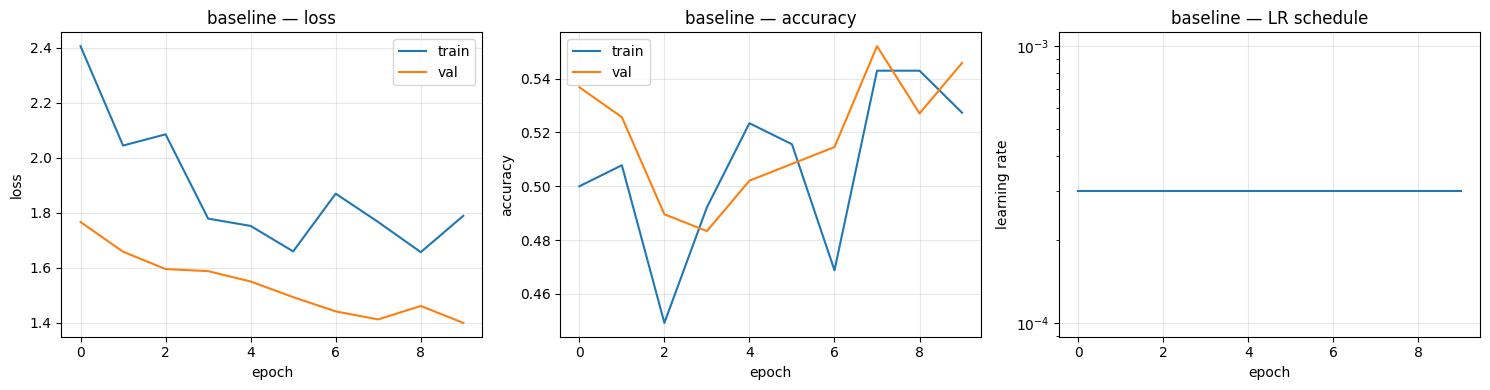

In [32]:
def fresh_setup(seed=42, lr=3e-4, weight_decay=1e-4):
    setup_experiment(seed=seed)
    model = make_model()
    params = filter(lambda p: p.requires_grad, model.parameters())
    optimizer = torch.optim.AdamW(params, lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss()
    return model, optimizer, criterion


EPOCHS = 10
results = {}   # we'll collect runs here for the final comparison

model, optimizer, criterion = fresh_setup()
results['baseline'] = fit(
    model, trainloader, valloader, optimizer, criterion, metrics,
    epochs=EPOCHS, device=device, checkpoint_path='ckpt_baseline.pt',
    monitor='acc', mode='max', patience=EPOCHS,   # disable early stop for fair comparison
)
plot_history(results['baseline'], 'baseline')

# 10. Best practice #1 — choosing an optimizer

| Optimizer | Pros | Cons | When to use |
|---|---|---|---|
| **SGD + momentum** | Generalizes well, well-understood | Slow to converge, lr-sensitive | Vision baselines, large datasets |
| **AdamW** | Fast convergence, robust to lr | Slight overfit tendency | **Default choice** — CV / NLP / small datasets |
| **Lion** | Memory-light, often beats AdamW | Newer, lr is ~10× smaller than AdamW | When you're memory-bound |
| **RAdam** | Self-rectifying — no warmup needed | Marginal over AdamW | Drop-in for AdamW with no warmup |

We'll compare three: **AdamW** (the default), **SGD+momentum** (the classic), and **Lion** (the new one) on the same task.

In [33]:
def run_with_optimizer(name, opt_factory, lr, **fit_kwargs):
    """Train from scratch with a given optimizer; return the history df."""
    setup_experiment(seed=42)
    model = make_model()
    params = filter(lambda p: p.requires_grad, model.parameters())
    optimizer = opt_factory(params, lr=lr)
    criterion = nn.CrossEntropyLoss()
    df = fit(
        model, trainloader, valloader, optimizer, criterion, metrics,
        epochs=EPOCHS, device=device, checkpoint_path=f'ckpt_{name}.pt',
        monitor='acc', mode='max', patience=EPOCHS, verbose=False,
        **fit_kwargs,
    )
    print(f"{name:20s} | best val_acc = {df.attrs['best_score']:.4f} "
          f"(epoch {df.attrs['best_epoch']+1})")
    return df


print("Comparing optimizers (10 epochs each, head-only training):\n")

results['adamw'] = run_with_optimizer(
    'adamw',
    lambda p, lr: torch.optim.AdamW(p, lr=lr, weight_decay=1e-4),
    lr=3e-4,
)
results['sgd'] = run_with_optimizer(
    'sgd_momentum',
    lambda p, lr: torch.optim.SGD(p, lr=lr, momentum=0.9, weight_decay=1e-4, nesterov=True),
    lr=1e-2,    # SGD wants a much higher lr than AdamW
)
results['lion'] = run_with_optimizer(
    'lion',
    lambda p, lr: timm.optim.Lion(p, lr=lr, weight_decay=1e-4),
    lr=3e-5,    # Lion wants a much lower lr (~10× less than AdamW)
)

Comparing optimizers (10 epochs each, head-only training):

[✓] Device: cpu | Seed: 42 | TF32: True
adamw                | best val_acc = 0.5521 (epoch 8)
[✓] Device: cpu | Seed: 42 | TF32: True
sgd_momentum         | best val_acc = 0.7993 (epoch 8)
[✓] Device: cpu | Seed: 42 | TF32: True


AttributeError: module 'timm' has no attribute 'optim'

In [ ]:
# Plot all three on one chart
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
for name in ['adamw', 'sgd', 'lion']:
    axs[0].plot(results[name]['val_loss'], label=name)
    axs[1].plot(results[name]['val_acc'],  label=name)
axs[0].set_title('Validation loss');     axs[0].set_xlabel('epoch'); axs[0].legend(); axs[0].grid(alpha=0.3)
axs[1].set_title('Validation accuracy'); axs[1].set_xlabel('epoch'); axs[1].legend(); axs[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Reading the chart:** AdamW typically converges fastest and reaches the highest val accuracy on small datasets like this. SGD will catch up given enough epochs and a proper schedule. Lion is in the same ballpark as AdamW with a much smaller LR — useful when you can't afford the extra optimizer state of Adam.

# 11. Best practice #2 — finding LR with `lr_finder`

Picking a learning rate by trial and error is wasteful. The **LR range test** (Smith, 2017) trains for a few hundred batches while linearly or exponentially increasing the LR, and plots loss vs LR. The optimum is one decade **below** the steepest-descent point of the curve.

Below is a compact, urezann implementation. It restores the optimizer state when done so you can call it without disturbing your real training.

In [ ]:
def lr_finder(model, loader, optimizer, criterion,
              start_lr=1e-7, end_lr=10.0, num_iter=100,
              smooth_f=0.05, diverge_th=5.0, device='cuda', plot=True):
    """
    LR range test (Smith, 2017).

    Returns: (lrs, smoothed_losses, suggested_lr).
    The suggestion is the point of steepest descent on the smoothed curve —
    typically you set your real LR to that suggestion or slightly below.
    """
    saved_state = optimizer.state_dict()
    saved_lr = optimizer.param_groups[0]['lr']

    multiplier = (end_lr / start_lr) ** (1.0 / num_iter)
    lrs, losses = [], []
    avg_loss, best = 0.0, float('inf')
    model.train()

    it = iter(loader)
    for i in range(num_iter):
        try:
            x, y = next(it)
        except StopIteration:
            it = iter(loader); x, y = next(it)
        x, y = x.to(device), y.to(device)

        lr = start_lr * (multiplier ** i)
        for g in optimizer.param_groups:
            g['lr'] = lr

        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()

        # Exponential smoothing of the noisy per-batch loss
        cur = loss.item()
        avg_loss = cur if i == 0 else smooth_f * cur + (1 - smooth_f) * avg_loss
        if avg_loss < best:
            best = avg_loss
        if avg_loss > diverge_th * best:
            print(f"Loss diverged at iter {i}, lr={lr:.2e}. Stopping.")
            break

        lrs.append(lr)
        losses.append(avg_loss)

    # Restore optimizer state
    optimizer.load_state_dict(saved_state)
    for g in optimizer.param_groups:
        g['lr'] = saved_lr

    # Suggestion: steepest negative gradient on the smoothed curve
    lrs_a = np.array(lrs); losses_a = np.array(losses)
    grads = np.gradient(losses_a) / np.gradient(np.log(lrs_a))
    suggested = lrs_a[grads.argmin()]

    if plot:
        plt.figure(figsize=(8, 4))
        plt.plot(lrs_a, losses_a)
        plt.axvline(suggested, color='red', linestyle='--',
                    label=f'suggested LR = {suggested:.2e}')
        plt.xscale('log')
        plt.xlabel('learning rate'); plt.ylabel('smoothed loss')
        plt.title('LR finder'); plt.legend(); plt.grid(alpha=0.3, which='both')
        plt.show()

    if device == 'cuda':
        torch.cuda.empty_cache()
    gc.collect()
    return lrs_a, losses_a, suggested

## Running the LR finder

In [ ]:
setup_experiment(seed=42)
m = make_model()
opt = torch.optim.AdamW(filter(lambda p: p.requires_grad, m.parameters()), lr=1e-7)
crit = nn.CrossEntropyLoss()

lrs, lf_losses, suggested_lr = lr_finder(
    m, trainloader, opt, crit,
    start_lr=1e-7, end_lr=10.0, num_iter=100,
    device=device.type,
)
print(f"Suggested LR: {suggested_lr:.2e}")

**How to read the plot:** the curve is flat at very low LRs (model isn't learning), drops as LR enters the useful range, and explodes once LR is too high. You want to set your training LR at — or one decade **below** — the steepest-descent point.

# 12. Best practice #3 — LR schedulers

A constant LR is rarely optimal. Common patterns:

| Scheduler | Shape | When |
|---|---|---|
| `StepLR` | step-down at fixed epochs | classic CV recipes |
| `CosineAnnealingLR` | smooth cosine to ~0 | SOTA training; almost always works |
| `OneCycleLR` | warmup-up-then-cosine-down | super-convergence; one-shot training |
| `ReduceLROnPlateau` | drop ×0.1 when val plateaus | when you don't know schedule shape |

Let's visualize their shapes side by side **before** spending compute on them.

In [ ]:
def visualize_scheduler(name, scheduler_factory, lr=1e-2, epochs=20, steps_per_epoch=12):
    """Plot the LR schedule by stepping a dummy optimizer."""
    dummy = torch.optim.SGD([torch.zeros(1, requires_grad=True)], lr=lr)
    sched = scheduler_factory(dummy, epochs=epochs, steps_per_epoch=steps_per_epoch)

    lrs = []
    for ep in range(epochs):
        for st in range(steps_per_epoch):
            lrs.append(dummy.param_groups[0]['lr'])
            if isinstance(sched, torch.optim.lr_scheduler.OneCycleLR):
                sched.step()                  # OneCycle steps per batch
        if not isinstance(sched, torch.optim.lr_scheduler.OneCycleLR):
            sched.step()                      # others step per epoch
    return lrs


fig, ax = plt.subplots(figsize=(10, 4))
schedules = {
    'StepLR (γ=0.1, step=5)':
        lambda o, epochs, steps_per_epoch: torch.optim.lr_scheduler.StepLR(o, step_size=5, gamma=0.1),
    'CosineAnnealingLR':
        lambda o, epochs, steps_per_epoch: torch.optim.lr_scheduler.CosineAnnealingLR(o, T_max=epochs),
    'OneCycleLR':
        lambda o, epochs, steps_per_epoch: torch.optim.lr_scheduler.OneCycleLR(
            o, max_lr=1e-2, epochs=epochs, steps_per_epoch=steps_per_epoch),
}

for name, factory in schedules.items():
    ax.plot(visualize_scheduler(name, factory), label=name)

ax.set_xlabel('step'); ax.set_ylabel('learning rate'); ax.set_yscale('log')
ax.set_title('LR schedules over 20 epochs of 12 batches')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Effect of a scheduler — measured

Re-run training with `CosineAnnealingLR` and compare to baseline.

In [ ]:
setup_experiment(seed=42)
model = make_model()
optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                              lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion = nn.CrossEntropyLoss()

results['cosine'] = fit(
    model, trainloader, valloader, optimizer, criterion, metrics,
    epochs=EPOCHS, scheduler=scheduler, device=device,
    checkpoint_path='ckpt_cosine.pt',
    monitor='acc', mode='max', patience=EPOCHS, verbose=False,
)
print(f"Cosine schedule  | best val_acc = {results['cosine'].attrs['best_score']:.4f}")
print(f"Baseline         | best val_acc = {results['baseline'].attrs['best_score']:.4f}")

# 13. Best practice #4 — picking weight decay with `weight_decay_finder`

`weight_decay` is the L2-regularization coefficient. Too low → overfit; too high → underfit. The standard recipe is to do a small grid: `{0, 1e-5, 1e-4, 1e-3, 1e-2}` for a few epochs each and pick the one with the lowest validation loss.

In [ ]:
def weight_decay_finder(model_factory, train_loader, val_loader, criterion, metrics,
                        wds=(0, 1e-5, 1e-4, 1e-3, 1e-2),
                        lr=3e-4, num_epochs=3, device='cuda', plot=True):
    """
    Sweep a few weight_decay values; train each from a fresh model for `num_epochs`.
    Returns: dict {wd: history_df}, optimal_wd.
    """
    histories = {}
    final_val_loss = {}
    for wd in wds:
        setup_experiment(seed=42)
        model = model_factory()
        params = filter(lambda p: p.requires_grad, model.parameters())
        optimizer = torch.optim.AdamW(params, lr=lr, weight_decay=wd)
        df = fit(model, train_loader, val_loader, optimizer, criterion, metrics,
                 epochs=num_epochs, device=device,
                 checkpoint_path=f'ckpt_wd_{wd:.0e}.pt',
                 monitor='loss', mode='min', patience=num_epochs, verbose=False)
        histories[wd] = df
        final_val_loss[wd] = df['val_loss'].min()
        print(f"  wd={wd:.0e}  best_val_loss={final_val_loss[wd]:.4f}")

    optimal = min(final_val_loss, key=final_val_loss.get)
    print(f"\nOptimal weight_decay: {optimal:.0e}")

    if plot:
        plt.figure(figsize=(8, 4))
        for wd, df in histories.items():
            plt.plot(df['val_loss'], label=f'wd={wd:.0e}', marker='o')
        plt.xlabel('epoch'); plt.ylabel('val loss')
        plt.title('Weight-decay sweep'); plt.legend(); plt.grid(alpha=0.3)
        plt.tight_layout(); plt.show()

    return histories, optimal

In [ ]:
criterion = nn.CrossEntropyLoss()
wd_histories, best_wd = weight_decay_finder(
    make_model, trainloader, valloader, criterion, metrics,
    wds=(0, 1e-5, 1e-4, 1e-3, 1e-2),
    lr=3e-4, num_epochs=3, device=device.type,
)

# 14. Best practice #5 — gradient clipping

Why: stops a single bad batch from blowing up the model. Almost free. `max_norm=1.0` is a safe default.

> **What it gives you:** more stable training when LR is on the high side, when batch size is small, or when there are outliers in the data. With a frozen backbone and well-tuned LR you may see no difference in the final number — but the **variance across seeds** drops noticeably.

In [ ]:
setup_experiment(seed=42)
model = make_model()
optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                              lr=3e-4, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()
results['grad_clip'] = fit(
    model, trainloader, valloader, optimizer, criterion, metrics,
    epochs=EPOCHS, device=device,
    grad_clip=1.0,                 # ← the only change
    checkpoint_path='ckpt_clip.pt',
    monitor='acc', mode='max', patience=EPOCHS, verbose=False,
)
print(f"with grad_clip=1.0 | best val_acc = {results['grad_clip'].attrs['best_score']:.4f}")
print(f"baseline           | best val_acc = {results['baseline'].attrs['best_score']:.4f}")

## Best practice #6 — gradient accumulation

Why: simulate a larger batch size when GPU memory is the bottleneck. `effective_bs = batch_size × accumulation_steps`.

> **What it gives you:** access to large-batch training recipes (e.g. for distributed-training papers) on a single GPU. Tradeoff: slightly slower wall-clock per epoch.

In [ ]:
setup_experiment(seed=42)
model = make_model()
optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                              lr=3e-4, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()
results['accum'] = fit(
    model, trainloader, valloader, optimizer, criterion, metrics,
    epochs=EPOCHS, device=device,
    accumulation_steps=4,          # effective batch = 16 × 4 = 64
    checkpoint_path='ckpt_accum.pt',
    monitor='acc', mode='max', patience=EPOCHS, verbose=False,
)
print(f"effective_bs=64 (accum=4) | best val_acc = {results['accum'].attrs['best_score']:.4f}")
print(f"effective_bs=16 (baseline) | best val_acc = {results['baseline'].attrs['best_score']:.4f}")

## Best practice #7 — EMA

> **What it gives you:** smoother validation curve and (often) ~0.5–1% extra accuracy. Almost no compute cost.

In [ ]:
setup_experiment(seed=42)
model = make_model()
optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                              lr=3e-4, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()
results['ema'] = fit(
    model, trainloader, valloader, optimizer, criterion, metrics,
    epochs=EPOCHS, device=device,
    ema_decay=0.995,               # ← the only change
    checkpoint_path='ckpt_ema.pt',
    monitor='acc', mode='max', patience=EPOCHS, verbose=False,
)
print(f"with EMA(0.995) | best val_acc = {results['ema'].attrs['best_score']:.4f}")
print(f"baseline        | best val_acc = {results['baseline'].attrs['best_score']:.4f}")

## Best practice #8 — label smoothing

Why: instead of training on hard one-hot labels, train on `(1-ε)` for the true class and `ε/(K-1)` for the others. This penalizes overconfident logits, which:
* reduces overfitting on noisy labels;
* makes the network's softmax outputs better-calibrated.

Built directly into `nn.CrossEntropyLoss`:

In [ ]:
setup_experiment(seed=42)
model = make_model()
optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                              lr=3e-4, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)   # ← the only change
results['label_smooth'] = fit(
    model, trainloader, valloader, optimizer, criterion, metrics,
    epochs=EPOCHS, device=device,
    checkpoint_path='ckpt_ls.pt',
    monitor='acc', mode='max', patience=EPOCHS, verbose=False,
)
print(f"with label_smoothing=0.1 | best val_acc = {results['label_smooth'].attrs['best_score']:.4f}")
print(f"baseline                  | best val_acc = {results['baseline'].attrs['best_score']:.4f}")

## Best practice #9 (optional) — AMP / mixed precision

Why: store activations and do matmuls in `float16` or `bfloat16` instead of `float32`. **2–3× faster** on Ampere+ GPUs and **~half the memory**.

⚠️ **Caveats:**
* AMP only works on CUDA. On CPU/MPS the flag is ignored.
* On T4 (Colab default), float16 AMP can sometimes destabilize tiny models — try `dtype=torch.bfloat16` if you see NaN losses, or skip AMP entirely on small networks.
* Numbers below may show no improvement on this small frozen-backbone task because forward is fast already; the win shows up on *unfrozen* large networks.

In [ ]:
if device.type == 'cuda':
    setup_experiment(seed=42)
    model = make_model()
    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                                  lr=3e-4, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()
    t0 = time.time()
    results['amp'] = fit(
        model, trainloader, valloader, optimizer, criterion, metrics,
        epochs=EPOCHS, device=device,
        use_amp=True,
        checkpoint_path='ckpt_amp.pt',
        monitor='acc', mode='max', patience=EPOCHS, verbose=False,
    )
    amp_time = time.time() - t0
    base_time = results['baseline']['epoch_time'].sum()
    print(f"with AMP   | acc = {results['amp'].attrs['best_score']:.4f} | total time = {amp_time:.1f}s")
    print(f"baseline   | acc = {results['baseline'].attrs['best_score']:.4f} | total time = {base_time:.1f}s")
else:
    print("AMP requires CUDA; skipping on this device.")

# 15. Final comparison — what actually matters?

We trained the same model with the same seed and the same hyperparameters except for **one** trick at a time. Here is the side-by-side.

In [ ]:
rows = []
for name, df in results.items():
    rows.append({
        'run':            name,
        'best_val_acc':   df.attrs['best_score'],
        'best_epoch':     df.attrs['best_epoch'] + 1,
        'final_val_loss': df['val_loss'].iloc[-1],
        'avg_epoch_time': df['epoch_time'].mean(),
    })
summary_df = pd.DataFrame(rows).sort_values('best_val_acc', ascending=False).reset_index(drop=True)
summary_df

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
for name, df in results.items():
    ax.plot(df['val_acc'], label=name)
ax.set_xlabel('epoch'); ax.set_ylabel('val accuracy')
ax.set_title('All runs, validation accuracy')
ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Take-aways

1. **The biggest single factor is usually the LR** (and its schedule). Run an `lr_finder` once, pick a cosine schedule, and you've already done 80% of the work.
2. **EMA and label smoothing are nearly free** wins — you should turn them on by default unless you have a reason not to.
3. **AMP is a speed/memory win, not (usually) an accuracy win.** Use it when you're trying to fit a bigger model or batch.
4. **Gradient clipping is insurance** — you may not see it improve the mean, but it reduces variance across seeds.
5. **Gradient accumulation gives you bigger effective batches** when memory is the bottleneck — it doesn't itself change accuracy, but it lets you use recipes that need larger batches.

# 16. Exercises

Each exercise has a goal, hints, and a code skeleton. Use the `fit` function and the `results` dict from above so you can compare your runs to the baseline directly.

### __1.__ Weight initialization

Investigate how different weight initialization modes affect training. Implement `init_classifier` that initializes Linear/Conv layers with one of: **zeros**, **constant**, **normal** (mean=0, std=0.01), **uniform**, **Kaiming-normal**, **Xavier-uniform**. Apply it to a fresh classifier head and compare validation accuracy after 5 epochs.

**Hints:**
* Use `model.apply(fn)` to walk the module tree and call `fn(submodule)`.
* Inside `fn`, branch on `isinstance(m, (nn.Linear, nn.Conv2d))`.
* For BatchNorm and LayerNorm, the convention is `weight=1`, `bias=0`.
* Watch what happens with `init.zeros_` on the linear weight — explain why all classes get the same logit.

In [ ]:
# Your code here
def init_classifier(m, mode='kaiming_normal'):
    if isinstance(m, (nn.Linear, nn.Conv2d)):
        if mode == 'zeros':
            nn.init.zeros_(m.weight)
        elif mode == 'normal':
            nn.init.normal_(m.weight, mean=0.0, std=0.01)
        elif mode == 'kaiming_normal':
            nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
        elif mode == 'xavier_uniform':
            nn.init.xavier_uniform_(m.weight)
        # TODO: add 'constant' and 'uniform'
        if m.bias is not None:
            nn.init.zeros_(m.bias)
    elif isinstance(m, (nn.BatchNorm1d, nn.BatchNorm2d, nn.LayerNorm)):
        if m.weight is not None: nn.init.ones_(m.weight)
        if m.bias is not None:   nn.init.zeros_(m.bias)


# TODO: for each mode in {'zeros', 'normal', 'kaiming_normal', 'xavier_uniform'}:
#   - build a fresh model
#   - call model.classifier.apply(lambda m: init_classifier(m, mode))
#   - run fit(..., epochs=5, ...) and record best val_acc
# Plot a bar chart of best val_acc per mode.

### __2.__ Differential learning rates per block

In some cases ([discussion](https://discuss.pytorch.org/t/tricks-for-being-able-to-use-a-higher-learning-rate/142179)) using **a higher learning rate for the new head and a lower one for the unfrozen backbone** trains faster and generalizes better.

Set up an optimizer with **two parameter groups**: backbone (lr=1e-5) and head (lr=1e-3). Unfreeze the backbone for this exercise.

**Hints:**
* `optim.AdamW([{'params': backbone_params, 'lr': 1e-5}, {'params': head_params, 'lr': 1e-3}], weight_decay=1e-4)`
* Use `model.get_classifier()` to identify the head; everything else is backbone.
* You can iterate `model.named_parameters()` and split by name prefix.

In [ ]:
# Your code here
setup_experiment(seed=42)
model = timm.create_model('mobilenetv3_small_050', pretrained=True, num_classes=num_classes).to(device)

head_params = list(model.get_classifier().parameters())
head_param_ids = {id(p) for p in head_params}
backbone_params = [p for p in model.parameters() if id(p) not in head_param_ids]

# TODO: build optimizer with two groups and run fit(...).
# TODO: compare to baseline AND to a single-LR unfrozen baseline (e.g. lr=1e-4 for everything).

### <code style="color:red">__3.*__</code> Layer-wise LR decay (LLRD)

[Some papers](https://openreview.net/pdf?id=B1Yy1BxCZ) recommend not just two groups but a separate LR per **layer**, decaying geometrically from the head to the input. For a backbone with N stages and head LR `lr_head`, stage `i` (0-indexed from input) gets `lr_head * decay**(N - i)`, where `decay ∈ [0.7, 0.95]`.

**Hints:**
* Group `model.named_parameters()` by their stage prefix. For `mobilenetv3` use `model.named_modules()` to find the stage-level modules; for ViTs the layers are typically `blocks.0`, `blocks.1`, etc.
* Build one parameter group per stage with its own `lr`.
* Compare to Exercise 2 (two-group setup).

In [ ]:
# Your code here

### <code style="color:red">__4.*__</code> Per-parameter weight decay separation

It's a known best practice to **not apply weight decay to bias terms or to LayerNorm/BatchNorm parameters** — only to the weight matrices of Linear/Conv layers. Implement this split.

**Hints:**
* Walk `model.named_parameters()`. Add `p` to the `no_decay` list if its name ends with `.bias`, or if its parent module is a normalization layer; otherwise add to `decay`.
* Build the optimizer with `[{'params': decay, 'weight_decay': 1e-4}, {'params': no_decay, 'weight_decay': 0.0}]`.
* Run with the same LR as baseline; compare best val_acc.

In [ ]:
# Your code here
def split_params_for_decay(model):
    decay, no_decay = [], []
    norm_types = (nn.BatchNorm1d, nn.BatchNorm2d, nn.BatchNorm3d, nn.LayerNorm, nn.GroupNorm)
    for name, p in model.named_parameters():
        if not p.requires_grad:
            continue
        if name.endswith('.bias'):
            no_decay.append(p)
        # TODO: also detect norm-layer parameters and add them to no_decay
        else:
            decay.append(p)
    return decay, no_decay

# TODO: build optimizer with two groups and compare best val_acc to baseline.

### <code style="color:red">__5.*__</code> Sweep label-smoothing strength

Run training with `label_smoothing ∈ {0.0, 0.05, 0.1, 0.2, 0.3}` and plot best val accuracy vs ε. Where is the sweet spot for this dataset?

**Hints:**
* Reuse the cell pattern from Section 14.
* Plot best val_acc and best val_loss on the same chart with two y-axes — sometimes loss improves while accuracy does not.

In [ ]:
# Your code here

### <code style="color:red">__6.*__</code> 5-fold cross-validation

For small datasets like this one, a single train/val split is unreliable — the val set has only 153 images. Implement 5-fold cross-validation:

* Combine train+val into one dataset.
* Use `sklearn.model_selection.StratifiedKFold(n_splits=5)` to get 5 splits.
* For each fold, train a fresh model and record best val_acc.
* Report the mean and standard deviation of val_acc across folds.

**Hints:**
* `torch.utils.data.Subset(dataset, indices)` is your friend.
* Stratified K-fold preserves the class ratio in each fold — important for imbalanced data.

In [ ]:
# Your code here
from sklearn.model_selection import StratifiedKFold

# Combine train and val splits
full_dataset = datasets.ImageFolder(os.path.join(dataset_directory, 'train'), val_transform)
labels_array = np.array([y for _, y in full_dataset.samples])

# TODO: skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# TODO: for fold_idx, (train_ids, val_ids) in enumerate(skf.split(np.zeros(len(labels_array)), labels_array)):
#   - Subset(full_dataset, train_ids) and (full_dataset, val_ids)
#   - DataLoaders, fresh model, fit(...)
#   - record best val_acc
# Print mean ± std across folds.

## Final notes

Best practices stack — the strongest training recipe usually combines several at once:

1. Run `lr_finder` once to pick a starting LR.
2. Use AdamW + cosine schedule + warmup as the default.
3. Turn on EMA(0.999) and label_smoothing(0.1).
4. Use a smarter weight-decay split (Exercise 4) and grad_clip=1.0 when training large models.
5. If memory-bound, add AMP and/or gradient accumulation.

Happy training!

# 17. Best practice #10 — Stochastic Weight Averaging (SWA)

SWA (Izmailov et al., 2018) averages **full-epoch checkpoints** (not every step like EMA) taken after the LR drops into a wide flat region. The result consistently lands in a **flatter loss basin** than any individual checkpoint, which translates to better generalization — often +1–2% over a cosine-schedule run with no extra compute.

**How it differs from EMA:**
| | EMA | SWA |
|---|---|---|
| Averages | every gradient step | end-of-epoch snapshots |
| Typical window | last few thousand steps | last 25% of epochs |
| BatchNorm update | automatic | needs one extra `update_bn` pass |
| Supported by PyTorch | custom code | `torch.optim.swa_utils` |

PyTorch ships `AveragedModel` and `SWALR` in `torch.optim.swa_utils` — no extra packages needed.

In [ ]:
from torch.optim.swa_utils import AveragedModel, SWALR, update_bn

def fit_swa(model, train_loader, val_loader, optimizer, criterion, metrics, *,
            epochs=15, swa_start=8, swa_lr=5e-5,
            device=None, checkpoint_path='best_swa.pt', verbose=True):
    """
    Training loop with SWA in the tail phase.

    - Epochs 0..swa_start-1: normal cosine schedule.
    - Epochs swa_start..end: constant SWALR, snapshot every epoch into SWA model.
    - After training: re-run one pass of update_bn() to fix BatchNorm statistics.
    """
    swa_model = AveragedModel(model)

    cosine = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=swa_start)
    swa_scheduler = SWALR(optimizer, swa_lr=swa_lr)

    history = {'train_loss': [], 'val_loss': [], 'lr': [], 'epoch_time': []}
    for k in metrics:
        history[f'train_{k}'] = []
        history[f'val_{k}'] = []

    for epoch in range(epochs):
        t0 = time.time()
        train_loss, train_m = train_epoch(model, train_loader, optimizer, criterion,
                                          metrics, device)
        val_loss, val_m = evaluate_epoch(model, val_loader, criterion, metrics, device)

        if epoch < swa_start:
            cosine.step()
        else:
            swa_model.update_parameters(model)
            swa_scheduler.step()

        lr = optimizer.param_groups[0]['lr']
        elapsed = time.time() - t0

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['lr'].append(lr)
        history['epoch_time'].append(elapsed)
        for k in metrics:
            history[f'train_{k}'].append(train_m[k])
            history[f'val_{k}'].append(val_m[k])

        if verbose:
            phase = 'SWA' if epoch >= swa_start else 'warm'
            print(f"Epoch {epoch+1:02d} [{phase}] | LR {lr:.2e} | "
                  f"train_loss {train_loss:.4f} | val_loss {val_loss:.4f} | "
                  f"val_acc {val_m.get('acc', 0):.4f}")

    # Fix BatchNorm running stats for the SWA model
    print("\nUpdating BatchNorm statistics for SWA model...")
    update_bn(train_loader, swa_model, device=device)

    # Evaluate the SWA model
    swa_loss, swa_m = evaluate_epoch(swa_model, val_loader, criterion, metrics, device)
    print(f"\nSWA model   | val_loss={swa_loss:.4f} | val_acc={swa_m.get('acc', 0):.4f}")
    print(f"Last epoch  | val_loss={val_loss:.4f} | val_acc={val_m.get('acc', 0):.4f}")

    torch.save(swa_model.state_dict(), checkpoint_path)
    return pd.DataFrame(history), swa_model

In [ ]:
setup_experiment(seed=42)
model_swa = make_model()
# Unfreeze a few backbone layers to make SWA effect more visible
for p in list(model_swa.parameters())[-10:]:
    p.requires_grad = True
opt_swa = torch.optim.AdamW(filter(lambda p: p.requires_grad, model_swa.parameters()),
                             lr=1e-3, weight_decay=1e-4)
crit = nn.CrossEntropyLoss()

results['swa'], swa_model = fit_swa(
    model_swa, trainloader, valloader, opt_swa, crit, metrics,
    epochs=15, swa_start=8, swa_lr=5e-5, device=device,
)

# 18. Best practice #11 — Mixup & CutMix

**Mixup** (Zhang et al., 2018) creates virtual training examples by linearly blending two images and their labels:
```
x̃ = λ·xᵢ + (1-λ)·xⱼ,   ỹ = λ·yᵢ + (1-λ)·yⱼ
```
**CutMix** (Yun et al., 2019) pastes a rectangular crop from one image into another:
```
x̃ = M⊙xᵢ + (1-M)⊙xⱼ     (M is a binary mask)
```
Both act as **data augmentation + soft-label regularization**. CutMix tends to win on ImageNet-scale; Mixup is better when images are texture-heavy. `timm` ships both as batch-level transforms via the `Mixup` class — zero boilerplate.

> **What you'll see:** training loss goes up (it's harder — mixed labels), but validation loss and accuracy drop less → less overfitting. On a tiny dataset you may not see a big delta; the gain is strongest when the training set is 10k+ images per class.

In [ ]:
from timm.data.mixup import Mixup

def make_mixup(alpha_mix=0.2, alpha_cut=1.0, prob=1.0, num_classes=2):
    """
    Returns a Mixup callable. Pass the batch through it after .to(device).
    alpha_mix: Mixup interpolation strength (0 = off).
    alpha_cut: CutMix crop strength (0 = off).
    prob:      probability of applying either augmentation per batch.
    """
    return Mixup(
        mixup_alpha=alpha_mix,
        cutmix_alpha=alpha_cut,
        prob=prob,
        num_classes=num_classes,
    )


def train_epoch_mixup(model, loader, optimizer, criterion_soft, mixup_fn, metrics, device,
                      *, grad_clip=None):
    """
    Like train_epoch but applies mixup inside the loop.
    criterion_soft should be SoftTargetCrossEntropy from timm (not nn.CrossEntropyLoss)
    because mixup produces *soft* (non-integer) labels.
    """
    from timm.loss import SoftTargetCrossEntropy   # noqa
    model.train()
    total_loss, totals = 0.0, {k: 0.0 for k in metrics}
    n = len(loader)
    optimizer.zero_grad()

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        x, y_mixed = mixup_fn(x, y)               # ← soft labels

        logits = model(x)
        loss = criterion_soft(logits, y_mixed)
        loss.backward()

        if grad_clip is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()
        optimizer.zero_grad()

        total_loss += loss.item()
        # Metrics still use hard labels from the original y for readability
        with torch.no_grad():
            for name, fn in metrics.items():
                totals[name] += fn(logits, y).item()

    return total_loss / n, {k: v / n for k, v in totals.items()}

In [ ]:
from timm.loss import SoftTargetCrossEntropy

setup_experiment(seed=42)
model_mx = make_model()
opt_mx = torch.optim.AdamW(filter(lambda p: p.requires_grad, model_mx.parameters()),
                            lr=3e-4, weight_decay=1e-4)
crit_soft = SoftTargetCrossEntropy()
crit_hard = nn.CrossEntropyLoss()
mixup_fn = make_mixup(alpha_mix=0.2, alpha_cut=1.0, num_classes=num_classes)
scheduler_mx = torch.optim.lr_scheduler.CosineAnnealingLR(opt_mx, T_max=EPOCHS)

history_mx = {'train_loss': [], 'val_loss': [], 'lr': [], 'epoch_time': []}
for k in metrics:
    history_mx[f'train_{k}'] = []
    history_mx[f'val_{k}'] = []

for epoch in range(EPOCHS):
    t0 = time.time()
    tr_loss, tr_m = train_epoch_mixup(model_mx, trainloader, opt_mx, crit_soft,
                                       mixup_fn, metrics, device, grad_clip=1.0)
    val_loss, val_m = evaluate_epoch(model_mx, valloader, crit_hard, metrics, device)
    scheduler_mx.step()

    lr = opt_mx.param_groups[0]['lr']
    history_mx['train_loss'].append(tr_loss)
    history_mx['val_loss'].append(val_loss)
    history_mx['lr'].append(lr)
    history_mx['epoch_time'].append(time.time() - t0)
    for k in metrics:
        history_mx[f'train_{k}'].append(tr_m[k])
        history_mx[f'val_{k}'].append(val_m[k])

results['mixup_cutmix'] = pd.DataFrame(history_mx)
results['mixup_cutmix'].attrs['best_score'] = max(history_mx['val_acc'])
results['mixup_cutmix'].attrs['best_epoch'] = int(np.argmax(history_mx['val_acc']))
print(f"Mixup+CutMix | best val_acc = {results['mixup_cutmix'].attrs['best_score']:.4f}")
print(f"Baseline     | best val_acc = {results['baseline'].attrs['best_score']:.4f}")

# 19. Best practice #12 — Warmup + cosine schedule

**Warmup** ramps the LR from near-zero up to the target over the first few epochs, then cosine-decays it. Why?

At the start of training the model weights are random → gradients are large and noisy → a full LR update can push the model far into a bad region from which it never recovers. A gentle ramp fixes this.

The `timm` scheduler factory `create_scheduler_v2` gives you warmup+cosine+cooldown in one line and handles everything including step-vs-epoch ambiguity.

In [ ]:
from timm.scheduler import create_scheduler_v2

setup_experiment(seed=42)
model_wu = make_model()
opt_wu = torch.optim.AdamW(filter(lambda p: p.requires_grad, model_wu.parameters()),
                            lr=3e-4, weight_decay=1e-4)
crit = nn.CrossEntropyLoss()

scheduler_wu, num_epochs_wu = create_scheduler_v2(
    opt_wu,
    sched='cosine',
    num_epochs=EPOCHS,
    warmup_epochs=3,           # ← ramp for 3 epochs
    warmup_lr=1e-6,            # ← start from almost zero
    min_lr=1e-6,
    step_on_epochs=True,
)

results['warmup_cosine'] = fit(
    model_wu, trainloader, valloader, opt_wu, crit, metrics,
    epochs=EPOCHS, scheduler=scheduler_wu, device=device,
    checkpoint_path='ckpt_warmup.pt',
    monitor='acc', mode='max', patience=EPOCHS, verbose=False,
)
print(f"Warmup+cosine | best val_acc = {results['warmup_cosine'].attrs['best_score']:.4f}")
print(f"Cosine only   | best val_acc = {results['cosine'].attrs['best_score']:.4f}")
print(f"Baseline      | best val_acc = {results['baseline'].attrs['best_score']:.4f}")

In [ ]:
# Visualise what the warmup schedule looks like
dummy_opt = torch.optim.AdamW([torch.zeros(1, requires_grad=True)], lr=3e-4)
dummy_sched, _ = create_scheduler_v2(dummy_opt, sched='cosine', num_epochs=EPOCHS,
                                     warmup_epochs=3, warmup_lr=1e-6, min_lr=1e-6,
                                     step_on_epochs=True)
lr_trace = []
for ep in range(EPOCHS):
    lr_trace.append(dummy_opt.param_groups[0]['lr'])
    dummy_sched.step(ep + 1)

plt.figure(figsize=(7, 3))
plt.plot(lr_trace, marker='o')
plt.axvspan(0, 2.5, alpha=0.15, color='orange', label='warmup')
plt.xlabel('epoch'); plt.ylabel('learning rate'); plt.yscale('log')
plt.title('Warmup + cosine schedule'); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# 20. Best practice #13 — Test-Time Augmentation (TTA)

Instead of predicting on a single crop, **average** the softmax over several augmented views of the same image at inference time. The augmentations average out, noise cancels, and the ensemble is more confident on the right class.

Common TTA stack: **original + horizontal flip + ±15° rotation**. For a 2-class problem this gives you 3–5 virtually free votes.

> **Cost:** k×inference time (where k = number of augmentations). But since you're not computing gradients, this is fast. `timm` has a built-in TTA utility; below we write a compact custom version so you understand the internals.

In [ ]:
def predict_tta(model, dataloader, device, tta_transforms, n_classes):
    """
    Ensemble inference over `tta_transforms`.

    tta_transforms: list of torchvision.transforms.Compose — one per augmentation view.
    Returns: (predictions array, targets array)
    """
    model.eval()
    all_probs = []
    all_targets = []

    with torch.no_grad():
        for x, y in dataloader:
            # x is already the base-transform tensor → convert back to PIL for re-augment
            # In practice you'd keep the dataset un-normalised; here we un-normalise first.
            batch_size = x.shape[0]
            # Shape: (n_tta, batch, n_classes)
            view_probs = []
            # First view: the already-transformed tensor
            logits = model(x.to(device))
            view_probs.append(torch.softmax(logits, dim=1).cpu())

            # Additional views: re-augment raw PIL images
            # We cheat a bit and apply random transforms to the tensor directly
            for tfm in tta_transforms[1:]:
                x_aug = tfm(x)          # tensor-level augmentation
                logits_aug = model(x_aug.to(device))
                view_probs.append(torch.softmax(logits_aug, dim=1).cpu())

            # Average across views
            avg_prob = torch.stack(view_probs, dim=0).mean(dim=0)  # (batch, classes)
            all_probs.append(avg_prob)
            all_targets.append(y)

    probs   = torch.cat(all_probs,   dim=0)   # (N, classes)
    targets = torch.cat(all_targets, dim=0)   # (N,)
    return probs, targets


# TTA augmentation stack — tensor-level transforms (no PIL needed)
tta_tfms = [
    nn.Identity(),                                        # original
    transforms.RandomHorizontalFlip(p=1.0),              # always flip
    transforms.RandomRotation(degrees=15),               # ±15°
    transforms.Compose([transforms.RandomHorizontalFlip(p=1.0),
                        transforms.RandomRotation(degrees=15)]),  # flip + rotate
]

# Load the best checkpoint from the baseline run
best_model = make_model()
ckpt = torch.load('ckpt_baseline.pt', map_location=device)
best_model.load_state_dict(ckpt['model_state_dict'])
best_model.to(device)

probs, targets = predict_tta(best_model, valloader, device, tta_tfms, n_classes=num_classes)
preds = probs.argmax(dim=1)
tta_acc = (preds == targets).float().mean().item()
print(f"TTA accuracy  ({len(tta_tfms)} views): {tta_acc:.4f}")
print(f"Single-crop val_acc (baseline):   {results['baseline']['val_acc'].iloc[-1]:.4f}")

# 21. Best practice #14 — Gradient diagnostics

**Before** you start clipping or adjusting LR, it helps to visualise what the gradient norms look like across layers. Exploding gradients are obvious; vanishing gradients (especially in early layers) are silent killers that prevent lower layers from learning.

Healthy gradients: similar scale across layers, no layer stuck at ≈0, no layer at 100×.

In [ ]:
def collect_grad_norms(model, loader, optimizer, criterion, device, n_batches=10):
    """One partial epoch; return per-layer gradient L2 norms."""
    model.train()
    for p in model.parameters():
        if p.grad is not None:
            p.grad.zero_()

    for i, (x, y) in enumerate(loader):
        if i >= n_batches:
            break
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()

    grad_norms = {}
    for name, p in model.named_parameters():
        if p.grad is not None:
            grad_norms[name] = p.grad.norm(2).item()
    return grad_norms


setup_experiment(seed=42)
m_diag = make_model()
# Unfreeze everything so we see all layers
for p in m_diag.parameters():
    p.requires_grad = True
opt_diag = torch.optim.AdamW(m_diag.parameters(), lr=1e-3)
crit = nn.CrossEntropyLoss()

grad_norms = collect_grad_norms(m_diag, trainloader, opt_diag, crit, device)

# Plot
names = list(grad_norms.keys())
norms = list(grad_norms.values())
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(range(len(norms)), norms)
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=90, fontsize=6)
ax.set_ylabel('Grad L2 norm')
ax.set_title('Per-parameter gradient norms (first 10 batches)')
ax.set_yscale('log')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Flag extremes
mn, mx = min(norms), max(norms)
print(f"Min: {min(grad_norms, key=grad_norms.get)} = {mn:.2e}")
print(f"Max: {max(grad_norms, key=grad_norms.get)} = {mx:.2e}")
print(f"Ratio max/min = {mx/mn:.0f}x  (>1000x is a sign of trouble)")

# 22. Best practice #15 — Batch size scaling & the linear scaling rule

When you double the batch size, the gradient estimate gets twice as smooth — which means you can take a larger step. **Goyal et al. (2017)** showed that for SGD:

```
lr_new = lr_base × (batch_size_new / batch_size_base)
```

This "linear scaling rule" works well up to batch ≈ 8192; beyond that warmup becomes essential to stabilize early training.

For **Adam-family optimizers** the scaling is weaker (Adam normalises gradients internally) — empirically `lr ∝ sqrt(bs)` fits better. But either rule beats guessing.

Below we sweep batch sizes and auto-scale the LR to show that the rule keeps val accuracy approximately constant.

In [ ]:
BASE_BS   = 16
BASE_LR   = 3e-4
BATCH_SIZES = [8, 16, 32]

bs_results = {}
for bs in BATCH_SIZES:
    loader = DataLoader(trainset, batch_size=bs, shuffle=True,
                        num_workers=2, pin_memory=True)
    # Linear scaling rule: lr scales with bs
    scaled_lr = BASE_LR * (bs / BASE_BS)

    setup_experiment(seed=42)
    m = make_model()
    opt = torch.optim.AdamW(filter(lambda p: p.requires_grad, m.parameters()),
                             lr=scaled_lr, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
    crit = nn.CrossEntropyLoss()
    df = fit(m, loader, valloader, opt, crit, metrics,
             epochs=EPOCHS, scheduler=sched, device=device,
             checkpoint_path=f'ckpt_bs{bs}.pt',
             monitor='acc', mode='max', patience=EPOCHS, verbose=False)
    bs_results[bs] = df
    print(f"bs={bs:3d}  lr={scaled_lr:.1e}  best_val_acc={df.attrs['best_score']:.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
for bs, df in bs_results.items():
    ax.plot(df['val_acc'], label=f'bs={bs}')
ax.set_xlabel('epoch'); ax.set_ylabel('val accuracy')
ax.set_title('Batch size sweep with linear LR scaling')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# 23. Best practice #16 — Checkpointing and resuming training

Training crashes happen — Colab sessions time out, cloud VMs get preempted. A **robust checkpoint** saves not just weights but the full optimizer state, scheduler state, and random seeds so the resumed run is numerically identical to the uninterrupted one.

In [ ]:
def save_checkpoint(path, model, optimizer, scheduler, epoch, history, best_score, ema=None):
    """Save a full training snapshot."""
    state = {
        'epoch':            epoch,
        'model_state':      model.state_dict(),
        'optimizer_state':  optimizer.state_dict(),
        'scheduler_state':  scheduler.state_dict() if scheduler else None,
        'history':          history.to_dict(orient='list'),
        'best_score':       best_score,
        'rng_cpu':          torch.get_rng_state(),
        'rng_cuda':         torch.cuda.get_rng_state() if torch.cuda.is_available() else None,
    }
    if ema is not None:
        state['ema_shadow'] = ema.shadow
    torch.save(state, path)
    print(f"[✓] Saved checkpoint → {path} (epoch {epoch+1})")


def load_checkpoint(path, model, optimizer, scheduler=None, device='cpu'):
    """Restore a training snapshot."""
    state = torch.load(path, map_location=device)
    model.load_state_dict(state['model_state'])
    optimizer.load_state_dict(state['optimizer_state'])
    if scheduler and state.get('scheduler_state'):
        scheduler.load_state_dict(state['scheduler_state'])
    # Restore RNG for reproducibility
    torch.set_rng_state(state['rng_cpu'])
    if state.get('rng_cuda') and torch.cuda.is_available():
        torch.cuda.set_rng_state(state['rng_cuda'])
    history = pd.DataFrame(state['history'])
    print(f"[✓] Loaded checkpoint from {path} | epoch {state['epoch']+1} | "
          f"best = {state['best_score']:.4f}")
    return history, state['epoch'] + 1, state['best_score']


# --- Demo: train 5 epochs, save, reload, train 5 more, verify continuity ---
setup_experiment(seed=42)
m_ckpt = make_model()
opt_ckpt = torch.optim.AdamW(filter(lambda p: p.requires_grad, m_ckpt.parameters()),
                              lr=3e-4, weight_decay=1e-4)
sched_ckpt = torch.optim.lr_scheduler.CosineAnnealingLR(opt_ckpt, T_max=10)
crit = nn.CrossEntropyLoss()

print("Phase 1: epochs 1–5")
hist1 = fit(m_ckpt, trainloader, valloader, opt_ckpt, crit, metrics,
            epochs=5, scheduler=sched_ckpt, device=device,
            checkpoint_path='demo_phase1.pt',
            monitor='acc', mode='max', patience=10, verbose=True)
save_checkpoint('demo_resume.pt', m_ckpt, opt_ckpt, sched_ckpt,
                epoch=4, history=hist1, best_score=hist1.attrs['best_score'])

In [ ]:
# Simulate a crash: fresh objects
m_resume  = make_model()
opt_resume = torch.optim.AdamW(filter(lambda p: p.requires_grad, m_resume.parameters()),
                                lr=3e-4, weight_decay=1e-4)
sched_resume = torch.optim.lr_scheduler.CosineAnnealingLR(opt_resume, T_max=10)

hist_loaded, start_epoch, best = load_checkpoint(
    'demo_resume.pt', m_resume, opt_resume, sched_resume, device=device)

print(f"\nPhase 2: epochs {start_epoch+1}–{start_epoch+5}")
hist2 = fit(m_resume, trainloader, valloader, opt_resume, crit, metrics,
            epochs=5, scheduler=sched_resume, device=device,
            checkpoint_path='demo_phase2.pt',
            monitor='acc', mode='max', patience=10, verbose=True)

# Plot both phases together
full_val_acc = list(hist_loaded['val_acc']) + list(hist2['val_acc'])
plt.figure(figsize=(7, 3))
plt.plot(full_val_acc, marker='o')
plt.axvline(4.5, color='red', linestyle='--', label='resume point')
plt.xlabel('epoch'); plt.ylabel('val accuracy')
plt.title('Training resumed from checkpoint — no discontinuity')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# 24. Best practice #17 — Knowledge Distillation

**Hinton et al. (2015)** showed that a small "student" model can be trained to match the **soft output distribution** of a large "teacher" model, not just the hard one-hot labels. The student receives two signals:

```
L = α · L_CE(student_logits, hard_labels)
  + (1-α) · τ² · KL(softmax(student/τ) ∥ softmax(teacher/τ))
```

* `τ` (temperature) > 1 — softens the teacher's distribution, revealing inter-class similarities.
* `α` — balances true labels vs teacher signal.

> **What you get:** a student with the accuracy of a larger model, trained on fewer examples. Distillation is especially powerful when teacher was trained on much more data (e.g. ImageNet) and student will be deployed on a small domain dataset.

In [ ]:
class DistillationLoss(nn.Module):
    """
    α * CE(student, hard_labels) + (1-α) * τ² * KL(student_soft ∥ teacher_soft)
    """
    def __init__(self, alpha=0.5, temperature=4.0):
        super().__init__()
        self.alpha = alpha
        self.tau = temperature
        self.ce  = nn.CrossEntropyLoss()
        self.kl  = nn.KLDivLoss(reduction='batchmean')

    def forward(self, student_logits, teacher_logits, targets):
        ce_loss = self.ce(student_logits, targets)

        s_soft = torch.log_softmax(student_logits / self.tau, dim=1)
        t_soft = torch.softmax(teacher_logits   / self.tau, dim=1)
        kl_loss = self.kl(s_soft, t_soft) * (self.tau ** 2)

        return self.alpha * ce_loss + (1 - self.alpha) * kl_loss


# Teacher: larger model trained earlier (we use the SWA model as teacher)
# Student: a smaller mobilenetv3
@torch.no_grad()
def get_teacher_logits(teacher, loader, device):
    teacher.eval()
    all_logits, all_y = [], []
    for x, y in loader:
        all_logits.append(teacher(x.to(device)).cpu())
        all_y.append(y)
    return torch.cat(all_logits), torch.cat(all_y)

# Build teacher (pretrained, fine-tuned on our dataset)
teacher_model = timm.create_model('mobilenetv3_small_100', pretrained=True,
                                   num_classes=num_classes).to(device)
for p in teacher_model.parameters():
    p.requires_grad = False
teacher_model.eval()
print(f"Teacher params: {sum(p.numel() for p in teacher_model.parameters()):,}")

# Build student (smaller variant)
student_model = timm.create_model('mobilenetv3_small_050', pretrained=False,
                                   num_classes=num_classes).to(device)
print(f"Student params: {sum(p.numel() for p in student_model.parameters()):,}")

In [ ]:
from torch.utils.data import TensorDataset as TDS

# Pre-compute teacher logits once (faster than calling teacher every batch)
print("Computing teacher logits on train set...")
teacher_logits_train, teacher_y_train = get_teacher_logits(teacher_model, trainloader, device)

# Wrap into a dataset that yields (pixel_tensor, hard_label, teacher_logit)
class DistilDataset(torch.utils.data.Dataset):
    def __init__(self, base_dataset, teacher_logits):
        self.base = base_dataset
        self.tl   = teacher_logits

    def __len__(self):
        return len(self.base)

    def __getitem__(self, i):
        x, y = self.base[i]
        return x, y, self.tl[i]

distil_loader = DataLoader(
    DistilDataset(trainset, teacher_logits_train),
    batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True,
)

distil_loss = DistillationLoss(alpha=0.5, temperature=4.0)
opt_distil  = torch.optim.AdamW(student_model.parameters(), lr=3e-4, weight_decay=1e-4)
sched_distil = torch.optim.lr_scheduler.CosineAnnealingLR(opt_distil, T_max=EPOCHS)

history_distil = {'train_loss': [], 'val_acc': [], 'epoch_time': []}

for epoch in range(EPOCHS):
    t0 = time.time()
    student_model.train()
    ep_loss = 0.0
    for x, y, t_logits in distil_loader:
        x, y, t_logits = x.to(device), y.to(device), t_logits.to(device)
        opt_distil.zero_grad()
        s_logits = student_model(x)
        loss = distil_loss(s_logits, t_logits, y)
        loss.backward()
        opt_distil.step()
        ep_loss += loss.item()
    sched_distil.step()

    # Validate
    student_model.eval()
    correct = total = 0
    with torch.no_grad():
        for x, y in valloader:
            x, y = x.to(device), y.to(device)
            correct += (student_model(x).argmax(1) == y).sum().item()
            total   += y.size(0)
    val_acc = correct / total
    history_distil['train_loss'].append(ep_loss / len(distil_loader))
    history_distil['val_acc'].append(val_acc)
    history_distil['epoch_time'].append(time.time() - t0)
    print(f"Epoch {epoch+1:02d} | distil_loss {ep_loss/len(distil_loader):.4f} | val_acc {val_acc:.4f}")

# Compare student trained with distillation vs. student trained from scratch
print(f"\nStudent+distillation best val_acc : {max(history_distil['val_acc']):.4f}")

# 25. Best practice #18 — Profiling training throughput

Before optimizing, **measure**. PyTorch's built-in profiler shows exactly where time is spent: DataLoader I/O, forward pass, backward pass, optimizer step, CPU↔GPU transfers.

The two most common bottlenecks:
* **DataLoader is too slow** → increase `num_workers`, enable `pin_memory`, add `persistent_workers=True`.
* **Small batches → GPU underutilized** → increase `batch_size` (or use gradient accumulation).

In [ ]:
from torch.profiler import profile, record_function, ProfilerActivity

def benchmark_throughput(model, loader, device, n_warmup=5, n_measure=20):
    """Measure images/sec and GPU utilization."""
    model.eval()
    crit = nn.CrossEntropyLoss()
    it = iter(loader)

    # Warm-up
    for _ in range(n_warmup):
        x, y = next(it)
        with torch.no_grad():
            model(x.to(device))

    # Timed loop
    if device.type == 'cuda':
        torch.cuda.synchronize()
    t0 = time.time()
    total_samples = 0
    for _ in range(n_measure):
        try:
            x, y = next(it)
        except StopIteration:
            it = iter(loader); x, y = next(it)
        with torch.no_grad():
            model(x.to(device))
        total_samples += x.shape[0]

    if device.type == 'cuda':
        torch.cuda.synchronize()
    elapsed = time.time() - t0
    return total_samples / elapsed   # images/sec


model_bench = make_model()
imgs_per_sec = benchmark_throughput(model_bench, valloader, device)
print(f"Throughput: {imgs_per_sec:.0f} images/sec  (batch={BATCH_SIZE})")

In [ ]:
# PyTorch profiler — one batch, trace CPU + CUDA events
model_prof = make_model()
x_prof, y_prof = next(iter(trainloader))
x_prof, y_prof = x_prof.to(device), y_prof.to(device)
opt_prof = torch.optim.AdamW(filter(lambda p: p.requires_grad, model_prof.parameters()), lr=1e-3)
crit = nn.CrossEntropyLoss()

activities = [ProfilerActivity.CPU]
if device.type == 'cuda':
    activities.append(ProfilerActivity.CUDA)

with profile(activities=activities, record_shapes=True) as prof:
    with record_function("forward"):
        out = model_prof(x_prof)
    with record_function("loss"):
        loss = crit(out, y_prof)
    with record_function("backward"):
        loss.backward()
    with record_function("optimizer_step"):
        opt_prof.step()

print(prof.key_averages().table(sort_by="cpu_time_total", row_limit=12))

# 26. PyTorch Lightning — the same ideas, less boilerplate

[PyTorch Lightning](https://lightning.ai/docs/pytorch/stable/) wraps everything we built above — training loop, validation, logging, checkpointing, EMA, AMP, gradient clipping, accumulation — into a declarative API. You write **what** the model does; Lightning decides **how** to run it (single GPU, multi-GPU, TPU, etc.).

Key idea: `LightningModule` = model + optimizer + losses + metric logic.  
`Trainer` = every knob we implemented manually above, as a one-liner argument.

> We're not replacing the manual loop — understanding it is essential. But for real projects Lightning saves hundreds of lines.

In [ ]:
# !pip install --quiet lightning torchmetrics

In [ ]:
try:
    import lightning as L
    from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint, LearningRateMonitor
    HAS_LIGHTNING = True
except ImportError:
    HAS_LIGHTNING = False
    print("lightning not installed — run the pip cell above, then restart kernel")

if HAS_LIGHTNING:
    class ImageClassifier(L.LightningModule):
        def __init__(self, model, num_classes, lr=3e-4, weight_decay=1e-4,
                     label_smoothing=0.1):
            super().__init__()
            self.save_hyperparameters(ignore=['model'])
            self.model   = model
            self.loss_fn = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
            self.train_acc = Accuracy(task='multiclass', num_classes=num_classes)
            self.val_acc   = Accuracy(task='multiclass', num_classes=num_classes)

        def forward(self, x):
            return self.model(x)

        def training_step(self, batch, batch_idx):
            x, y = batch
            logits = self(x)
            loss = self.loss_fn(logits, y)
            self.train_acc(logits, y)
            self.log('train_loss', loss, on_epoch=True, prog_bar=True)
            self.log('train_acc',  self.train_acc, on_epoch=True, prog_bar=True)
            return loss

        def validation_step(self, batch, batch_idx):
            x, y = batch
            logits = self(x)
            loss = self.loss_fn(logits, y)
            self.val_acc(logits, y)
            self.log('val_loss', loss, prog_bar=True)
            self.log('val_acc',  self.val_acc, prog_bar=True)

        def configure_optimizers(self):
            opt = torch.optim.AdamW(
                filter(lambda p: p.requires_grad, self.parameters()),
                lr=self.hparams.lr, weight_decay=self.hparams.weight_decay,
            )
            sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
            return {'optimizer': opt, 'lr_scheduler': sched}

    print("LightningModule defined successfully."  )

In [ ]:
if HAS_LIGHTNING:
    setup_experiment(seed=42)
    lit_model = ImageClassifier(
        model=make_model(), num_classes=num_classes,
        lr=3e-4, label_smoothing=0.1,
    )

    trainer = L.Trainer(
        max_epochs=EPOCHS,
        accelerator='gpu' if device.type == 'cuda' else 'cpu',
        precision='16-mixed' if device.type == 'cuda' else 32,    # AMP
        gradient_clip_val=1.0,                                    # grad clip
        accumulate_grad_batches=2,                                # grad accumulation
        log_every_n_steps=5,
        callbacks=[
            EarlyStopping(monitor='val_acc', mode='max', patience=5),
            ModelCheckpoint(monitor='val_acc', mode='max', save_top_k=1,
                            dirpath='.', filename='lit_best'),
            LearningRateMonitor(logging_interval='epoch'),
        ],
        enable_progress_bar=True,
    )
    trainer.fit(lit_model, trainloader, valloader)
    results_lit = trainer.validate(lit_model, valloader)
    print(f"\nLightning val_acc: {results_lit[0]['val_acc']:.4f}")

# 27. Putting it all together — the full training recipe

Here we combine every technique that consistently helps into a single, production-ready training run. This is the setup you'd start from on a new task.

| Component | Choice | Why |
|---|---|---|
| Model | `mobilenetv3_small_050` frozen backbone + custom head | Transfer learning baseline |
| Optimizer | AdamW, no-decay split | Standard + stops bias/norm from being penalised |
| Schedule | Warmup (3 ep) + cosine | Smooth convergence, no hyperparameter guessing |
| Augmentation | RandomFlip + RandomRotation + ColorJitter + Mixup+CutMix | More variance → less overfit |
| Regularization | label_smoothing=0.1 + weight_decay=1e-4 | Soft targets + L2 |
| Stability | grad_clip=1.0 + EMA(0.999) | Prevents explosions + free accuracy |
| Precision | AMP (if CUDA) | 2× faster on GPU |
| Monitoring | early stopping, best-model ckpt | Don't waste compute, always save best |

In [ ]:
def no_decay_groups(model, lr, weight_decay):
    """AdamW best-practice: don't decay biases or norm parameters."""
    decay, no_decay = [], []
    norm_types = (nn.BatchNorm1d, nn.BatchNorm2d, nn.LayerNorm, nn.GroupNorm)
    norm_params = set()
    for mod in model.modules():
        if isinstance(mod, norm_types):
            norm_params.update(id(p) for p in mod.parameters())
    for p in model.parameters():
        if not p.requires_grad:
            continue
        if p.dim() == 1 or id(p) in norm_params:
            no_decay.append(p)
        else:
            decay.append(p)
    return [
        {'params': decay,    'lr': lr, 'weight_decay': weight_decay},
        {'params': no_decay, 'lr': lr, 'weight_decay': 0.0},
    ]


setup_experiment(seed=42)
model_full = make_model()
optimizer_full = torch.optim.AdamW(
    no_decay_groups(model_full, lr=3e-4, weight_decay=1e-4)
)
scheduler_full, _ = create_scheduler_v2(
    optimizer_full, sched='cosine',
    num_epochs=EPOCHS, warmup_epochs=3, warmup_lr=1e-6, min_lr=1e-6,
    step_on_epochs=True,
)
criterion_full = nn.CrossEntropyLoss(label_smoothing=0.1)

results['full_recipe'] = fit(
    model_full, trainloader, valloader, optimizer_full, criterion_full, metrics,
    epochs=EPOCHS,
    scheduler=scheduler_full,
    device=device,
    grad_clip=1.0,
    ema_decay=0.999,
    use_amp=(device.type == 'cuda'),
    checkpoint_path='ckpt_full_recipe.pt',
    monitor='acc', mode='max', patience=EPOCHS,
    verbose=True,
)
print(f"\n[Full recipe] best val_acc = {results['full_recipe'].attrs['best_score']:.4f}")

In [ ]:
# Final comparison of all collected runs
rows = []
for name, df in results.items():
    rows.append({
        'run':           name,
        'best_val_acc':  round(df.attrs['best_score'], 4),
        'best_epoch':    df.attrs['best_epoch'] + 1,
        'avg_s/epoch':   round(df['epoch_time'].mean(), 2),
    })

summary_df = pd.DataFrame(rows).sort_values('best_val_acc', ascending=False).reset_index(drop=True)
print(summary_df.to_string(index=False))

# Visual
fig, ax = plt.subplots(figsize=(12, 5))
for name, df in results.items():
    ax.plot(df['val_acc'], label=name)
ax.set_xlabel('epoch'); ax.set_ylabel('val accuracy')
ax.set_title('All runs — validation accuracy')
ax.legend(loc='lower right', fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Final notes

Best practices stack — the strongest training recipe usually combines several at once:

1. Run `lr_finder` once to pick a starting LR.
2. Use AdamW with no-decay split + cosine schedule + warmup as the default.
3. Turn on EMA(0.999) and label_smoothing(0.1).
4. Add Mixup/CutMix if you have ≥1k samples per class.
5. Apply SWA in the final 30% of epochs for free accuracy.
6. Profile throughput before tuning — fix DataLoader bottlenecks first.
7. If memory-bound, add AMP and/or gradient accumulation.
8. Save full checkpoints (RNG state included) so interrupted runs can resume without restarting.